In [4]:
import torch
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from NO import *
import pickle

random.seed(100)
device = "cpu"

ModuleNotFoundError: No module named 'NO'

In [ ]:
def train(dataloader, model, loss_fn, optimizer, device = "cpu"):
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)     
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def test(dataloader, model, loss_fn, device = "cpu"):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss += loss_fn(pred, y).item()
    loss /= num_batches
    return loss

In [2]:
# inputs [B, Nx, Nf]
# outputs [B, Nx, Nt, Nf]
def make_training_testing_datasets(data, history, batch_size):

    # select
    features = torch.tensor(data[:-history, :])
    labels = [torch.tensor(data[i:i+history, :]).t() for i in range(len(data)-history)]

    # re-arrange
    features = torch.reshape(features, features.shape + (1,)).to(torch.float32)
    labels = torch.stack(labels)
    labels = torch.reshape(labels, labels.shape + (1,)).to(torch.float32)

    # create datasets
    training_size = 1024
    idx = torch.randperm(training_size)
    training_dataset = TensorDataset(features[idx, :, :], labels[idx, :, :, :])
    testing_dataset = TensorDataset(features[training_size:, :, :], labels[training_size:, :, :, :])

    # create dataloaders
    training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
    testing_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

    dimensions = labels.shape
    
    return training_dataloader, testing_dataloader, dimensions

In [3]:
# Load PDE solution
with open('data/KuramotoSivashinsky/KS_N32.pkl', 'rb') as file:
    data = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'data/KuramotoSivashinsky/KS_N32.pkl'

In [4]:
# create data structures
history = 5
batch_size = 64
training_dataloader, testing_dataloader, dimensions = make_training_testing_datasets(data, history, batch_size)

In [34]:
# initialize operator
Nf = dimensions[-1]
Nx = dimensions[1]
Nlifted = 16
Nk_truncated = 8
depth = 1
neuralop = WNO(Nx, Nf, Nlifted, Nk_truncated, depth, 'db4').to(device) # lifted dim: not too small, not too large # fourier layer: not too deep
loss_fn = torch.nn.MSELoss(reduction='mean')
rate = 2E-04
optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)
progress = []

In [35]:
# train
epochs = 600
for i in range(epochs):
    train(training_dataloader, neuralop, loss_fn, optimizer_neuralop)
    progress += [test(testing_dataloader, neuralop, loss_fn)]
    if i%100==0:
        print(f"Loss: {(progress[-1]):>0.5f}")
        rate *= 0.5
        optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)
    if np.isnan(progress[-1]): 
        print('nan!')
        break
print(f'final learning rate: {rate}')
plt.figure()
plt.plot(progress)
plt.loglog()

Loss: 0.83506
Loss: 0.34935
Loss: 0.34991
Loss: 0.35093


KeyboardInterrupt: 

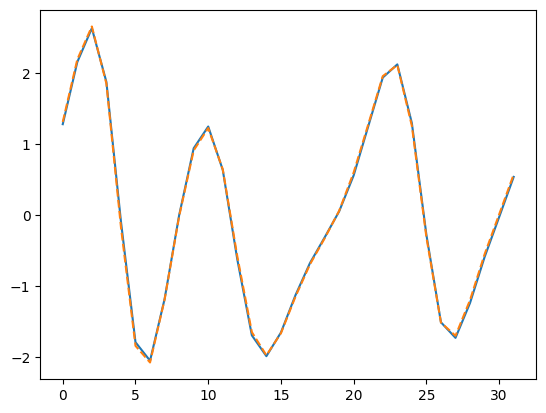

KeyboardInterrupt: 

In [404]:
# unroll, a priori model
# test one-step-in-future prediction
neuralop.eval()
fig, ax = plt.subplots()
for i in range(data_truncated[training_size:, :].size()[0]):
    uin = torch.reshape(data_truncated[i+training_size, :].to(torch.float32), (1, features.size()[1], 1))
    clear_output(wait=True)
    fig, ax = plt.subplots()
    u_pred = neuralop(uin)
    ax.plot(data_truncated[i+dt+training_size, :])
    ax.plot(u_pred.detach().numpy().squeeze(), '--')
    plt.show()
    plt.pause(0.1)

In [37]:
# train on low-res, apply to high-res
# Apply model on higher prediction data
# first, load the data
with open('data/KuramotoSivashinsky/KS_N118.pkl', 'rb') as file:
    data_hr = pickle.load(file)
data_hr = torch.tensor(data_hr)
Nx_hr = data_hr.size()[1]

history = 1
dt = 1 # increasing this too much is bad
data_hr = data_hr[:history*(data_hr.size()[0]//history), :]

# dataloader
features = data_hr[training_size:-dt, :].to(torch.float32)
features = torch.reshape(features, (features.size()[0], features.size()[1], 1))

labels = data_hr[training_size+dt:, :].to(torch.float32)
labels = torch.reshape(labels, (labels.size()[0], labels.size()[1], 1))

testing_dataset_hr = TensorDataset(features, labels)
batch_size = 64
testing_dataloader_hr = DataLoader(testing_dataset_hr, batch_size=batch_size, shuffle=False)

In [38]:
# test on higher resolution data
# downsample, predict, upsample (in Fourier space, but can use wavelets)

# X: batch of tensors
# Nx: target resolution (smaller)
def fft_downsample(X, Nx):
    X = torch.fft.rfft(X, dim=1, norm="backward")
    return torch.fft.irfft(X[:, :Nx//2+1, :], dim=1, norm="backward")

def fft_upsample(X, Nx, Nx_hr):
    batch_size = X.size()[0]
    X = torch.fft.rfft(X, dim=1, norm="backward")
    X = torch.cat((X[:, :Nx//2+1, :], torch.zeros((batch_size, Nx_hr//2-Nx//2, 1))), 1)
    X = torch.fft.irfft(X, dim=1, norm="backward")
    return X

def test_hr(dataloader, model, loss_fn, Nx):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            Nx_hr = X.size()[1]
            batch_size = X.size()[0]

            # downsample
            X = fft_downsample(X, Nx)

            # predict
            pred = model(X).detach()

            # upsample
            pred = fft_upsample(pred, Nx, Nx_hr)

            # loss
            loss += loss_fn(pred, y).item()
            
    loss /= num_batches
    return loss

In [39]:
progress = test_hr(testing_dataloader_hr, neuralop, loss_fn, Nx)
print(progress)

0.012858256581239402


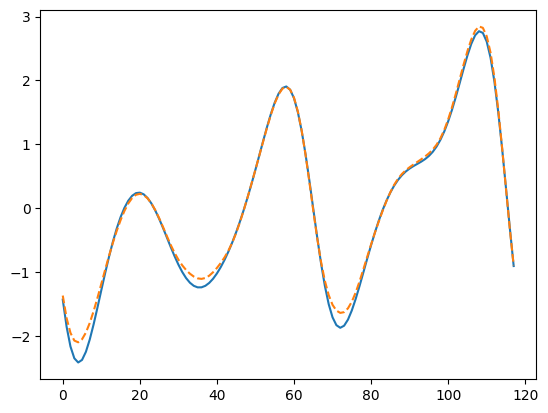

KeyboardInterrupt: 

In [36]:
# plot results
neuralop.eval()
for i in range(data_hr.size()[0]-dt):
    uin = torch.reshape(data_hr[i, :].to(torch.float32), (1, Nx_hr, 1))
    # downsample
    uin = fft_downsample(uin, Nx)

    # predict
    u_pred = neuralop(uin).detach()

    # upsample
    u_pred = fft_upsample(u_pred, Nx, Nx_hr)
    
    clear_output(wait=True)
    fig, ax = plt.subplots()
    
    ax.plot(data_hr[i+dt, :])
    ax.plot(u_pred.detach().numpy().squeeze(), '--')
    plt.show()
    plt.pause(0.1)

In [45]:
# test on a different timeseries (different initial condition)
with open('data/KuramotoSivashinsky/KS_N32_newInitial.pkl', 'rb') as file:
    data_ni = pickle.load(file)
data_ni = torch.tensor(data_ni)

history = 1
dt = 1 # increasing this too much is bad
data_ni = data_ni[:history*(data_ni.size()[0]//history), :]

# dataloader
features = data_ni[training_size:-dt, :].to(torch.float32)
features = torch.reshape(features, (features.size()[0], features.size()[1], 1))

labels = data_ni[training_size+dt:, :].to(torch.float32)
labels = torch.reshape(labels, (labels.size()[0], labels.size()[1], 1))

testing_dataset_ni = TensorDataset(features, labels)
batch_size = 64
testing_dataloader_ni = DataLoader(testing_dataset_ni, batch_size=batch_size, shuffle=False)

In [46]:
progress = test(testing_dataloader_ni, neuralop, loss_fn)
print(progress)

0.000683676920743892


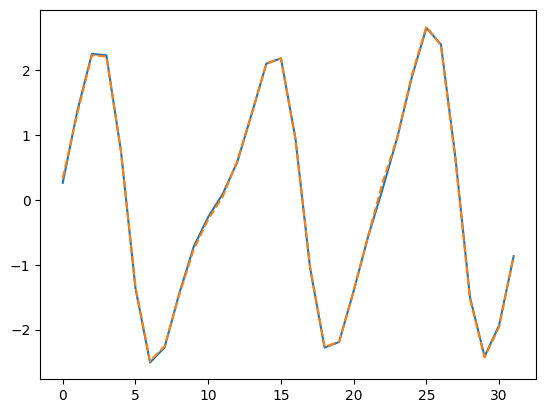

KeyboardInterrupt: 

In [47]:
# plots
neuralop.eval()
fig, ax = plt.subplots()
for i in range(data_ni.size()[0]):
    uin = torch.reshape(data_ni[i, :].to(torch.float32), (1, features.size()[1], 1))
    clear_output(wait=True)
    fig, ax = plt.subplots()
    u_pred = neuralop(uin)
    ax.plot(data_ni[i+dt, :])
    ax.plot(u_pred.detach().numpy().squeeze(), '--')
    plt.show()
    plt.pause(0.1)